# Radiomic Feature Extraction with PyRadiomics

This notebook demonstrates how to extract intensity- and shape-based radiomic features
from segmented mammographic masses using [PyRadiomics](https://www.radiomics.io/pyradiomics.html).

**Workflow:**
1. Set the dataset path and configure PyRadiomics from a YAML parameter file.
2. Preview a sample image/mask pair.
3. Inspect available feature classes and configure the extractor.
4. Extract features for the full dataset.
5. Export selected features to a CSV file.

**Input:** Pairs of `.pgm` files produced by `run_segmentation.m`:
- `<caseID>_resized.pgm` — preprocessed image
- `<caseID>_mass_mask.pgm` — binary lesion mask

**Requirements:** PyRadiomics, SimpleITK, Pillow, NumPy  
Install with: `pip install pyradiomics` (or from source; see cell below)

## 0. Installation

Uncomment and run the appropriate line if PyRadiomics is not yet installed.

In [39]:
# Standard release (may lag behind latest fixes):
# !pip install pyradiomics

# Latest development version from GitHub (recommended if the release has issues):
#!pip install git+https://github.com/AIM-Harvard/pyradiomics

## 1. Imports and dataset path

In [40]:
import os
import glob
import csv

import numpy as np
from PIL import Image
import SimpleITK as sitk
from radiomics import featureextractor, getFeatureClasses

### 1.a Reading data from a drive folder

In [41]:
# Change this to point at your dataset.
# Path to the drive folder containing the segmented PGM images.
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [42]:
# Path to the drive folder containing the segmented PGM images.
!unzip -q /content/gdrive/MyDrive/DATASETS/IMAGES/Mammography_masses/small_sample_Im_segmented_ref.zip -d /content/
DATASET_PATH = "/content/small_sample_Im_segmented_ref"

replace /content/small_sample_Im_segmented_ref/0088b1_3_1_1_mass_mask.pgm? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [43]:
# Path to the PyRadiomics YAML configuration file.
!cp /content/gdrive/MyDrive/Colab\ Notebooks/CMEPDA/L5_code/Params_tol_0_0001.yaml /content/.
PARAMS_PATH = "Params_tol_0_0001.yaml"

# Output CSV filename.
OUTPUT_CSV = "extracted_features.csv"

### 1.b Reading data from a local folder

In [44]:
# Path to the local folder containing the segmented PGM images.
# Change this to point at your dataset.
# DATASET_PATH = "/path/to/Im_segmented/"
#DATASET_PATH = "/Users/retico/Desktop/CMEPDA/DATASETS/IMAGES/Mammography_masses/large_sample_Im_segmented_ref/"

# Path to the PyRadiomics YAML configuration file.
#PARAMS_PATH = "Params_tol_0_0001.yaml"

# Output CSV filename.
#OUTPUT_CSV = "extracted_features.csv"

## 2. Preview a sample image and mask

We use [Pillow](https://python-pillow.org/) to load `.pgm` files for display.
PyRadiomics itself does not support this format natively, so we will convert
images to SimpleITK objects before feature extraction (see Section 4).

In [45]:
# List all resized images to confirm the dataset is reachable.
image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*_resized.pgm")))
mask_paths  = sorted(glob.glob(os.path.join(DATASET_PATH, "*_mass_mask.pgm")))

print(f"Found {len(image_paths)} image(s) and {len(mask_paths)} mask(s).")
assert len(image_paths) == len(mask_paths), \
    "Mismatch between number of images and masks — check DATASET_PATH."

Found 8 image(s) and 8 mask(s).


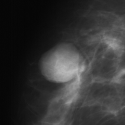

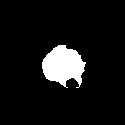

In [46]:
# Display the first image/mask pair as a quick sanity check.
if image_paths:
    display(Image.open(image_paths[0]))   # preprocessed image
    display(Image.open(mask_paths[0]))    # binary lesion mask

## 3. Initialise the PyRadiomics feature extractor

The extractor is configured from `Params_tol_0_0001.yaml`, which specifies:
- **Preprocessing settings** (bin width, resampling, geometry tolerance, …)
- **Image types** to compute features on (e.g., `Original`, `Wavelet`)
- **Feature classes** to enable (e.g., `firstorder`, `glcm`, `shape`, …)

Settings can also be adjusted programmatically after loading (see examples below).

In [47]:
extractor = featureextractor.RadiomicsFeatureExtractor(PARAMS_PATH)

print("Extraction settings:")
print("  ", extractor.settings)
print("\nEnabled image types:")
for image_type in extractor.enabledImagetypes:
    print(" ", image_type)
print("\nEnabled feature classes:")
print("  ", extractor.enabledFeatures)

INFO:radiomics.featureextractor:Loading parameter file Params_tol_0_0001.yaml


Extraction settings:
   {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'binWidth': 25, 'weightingNorm': None, 'geometryTolerance': 0.0001}

Enabled image types:
  Original

Enabled feature classes:
   {'shape': None, 'firstorder': [], 'glcm': ['Autocorrelation', 'JointAverage', 'ClusterProminence', 'ClusterShade', 'ClusterTendency', 'Contrast', 'Correlation', 'DifferenceAverage', 'DifferenceEntropy', 'DifferenceVariance', 'JointEnergy', 'JointEntropy', 'Imc1', 'Imc2', 'Idm', 'Idmn', 'Id', 'Idn', 'InverseVariance', 'MaximumProbability', 'SumEntropy', 'SumSquares'], 'glrlm': None, 'glszm': None, 'gldm': None}


### Optional: inspect, add, or remove image types and feature classes

The cells below show how to modify extractor settings **after** loading the YAML.
Run only the ones you need.

In [48]:
# Print all available feature classes and their member features.
feature_classes = getFeatureClasses()
print("Available feature classes:", list(feature_classes.keys()))

Available feature classes: ['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm', 'shape', 'shape2D']


In [49]:
# Example: enable Wavelet image type (applies all wavelet sub-bands).
extractor.enableImageTypeByName("Wavelet")

# Confirm enabled image types.
print("Enabled image types after update:", list(extractor.enabledImagetypes.keys()))

Enabled image types after update: ['Original', 'Wavelet']


In [50]:
# Example: restrict features to a specific subset.
# This disables all classes first, then enables only Mean and Skewness
# from the first-order class. Comment out if you want all features from the YAML.
extractor.disableAllFeatures()
extractor.enableFeaturesByName(firstorder=["Mean", "Skewness"])

print("Enabled features:", extractor.enabledFeatures)

Enabled features: {'firstorder': ['Mean', 'Skewness']}


In [51]:
# Optional: print docstrings for all currently active features.
print("Active features and their definitions:\n")
for cls_name, feature_list in extractor.enabledFeatures.items():
    # If the list is empty, all non-deprecated features for this class are active.
    if not feature_list:
        feature_list = [
            name for name, deprecated
            in feature_classes[cls_name].getFeatureNames().items()
            if not deprecated
        ]
    for feature_name in feature_list:
        getter = getattr(feature_classes[cls_name], f"get{feature_name}FeatureValue")
        print(f"  [{cls_name}] {feature_name}")
        print(getter.__doc__)

Active features and their definitions:

  [firstorder] Mean

        **8. Mean**

        .. math::
          \textit{mean} = \frac{1}{N_p}\displaystyle\sum^{N_p}_{i=1}{\textbf{X}(i)}

        The average gray level intensity within the ROI.
        
  [firstorder] Skewness

        **16. Skewness**

        .. math::
          \textit{skewness} = \displaystyle\frac{\mu_3}{\sigma^3} =
          \frac{\frac{1}{N_p}\sum^{N_p}_{i=1}{(\textbf{X}(i)-\bar{X})^3}}
          {\left(\sqrt{\frac{1}{N_p}\sum^{N_p}_{i=1}{(\textbf{X}(i)-\bar{X})^2}}\right)^3}

        Where :math:`\mu_3` is the 3\ :sup:`rd` central moment.

        Skewness measures the asymmetry of the distribution of values about the Mean value. Depending on where the tail is
        elongated and the mass of the distribution is concentrated, this value can be positive or negative.

        Related links:

        https://en.wikipedia.org/wiki/Skewness

        .. note::
          In case of a flat region, the standard deviation 

## 4. Single-case test run

PyRadiomics accepts NIfTI files (`.nii.gz`) or SimpleITK image objects directly.
Because our images are in `.pgm` format (not natively supported by SimpleITK),
we first load them with Pillow, convert to a NumPy array, then wrap in a
SimpleITK object.

In [52]:
def pgm_to_sitk(file_path: str) -> sitk.Image:
    """Load a PGM image and return it as a SimpleITK Image object."""
    array = np.asarray(Image.open(file_path))
    return sitk.GetImageFromArray(array)

In [53]:
# Run the extractor on the first image/mask pair as a sanity check.
# The mask label value 255 corresponds to foreground pixels in the PGM mask.
sample_image = pgm_to_sitk(image_paths[0])
sample_mask  = pgm_to_sitk(mask_paths[0])

print("Running extractor on:", os.path.basename(image_paths[0]))
sample_features = extractor.execute(sample_image, sample_mask, label=255)

print(f"\nExtracted {len(sample_features)} entries (including diagnostics).")
print("\nFeature dictionary (first 10 entries):")
for key, value in list(sample_features.items())[:10]:
    print(f"  {key}: {value}")

Running extractor on: 0008p1_3_1_2_resized.pgm


INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Adding image type "Wavelet" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.imageoperations:Computing Wavelet LH
INFO:radiomics.featureextractor:Calculating features for wavelet-LH image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.imageoperations:Computing Wavelet HL
INFO:radiomics.featureextractor:Calculating features for wavelet-HL image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.imageoperations:Computing Wavelet HH
INFO:radiomics.featureextractor:Calculating features for wavelet-HH image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Calculating


Extracted 32 entries (including diagnostics).

Feature dictionary (first 10 entries):
  diagnostics_Versions_PyRadiomics: 3.1.1.dev111+g8ed579383
  diagnostics_Versions_Numpy: 2.0.2
  diagnostics_Versions_SimpleITK: 2.5.3
  diagnostics_Versions_PyWavelet: 1.8.0
  diagnostics_Versions_Python: 3.12.13
  diagnostics_Configuration_Settings: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 255, 'additionalInfo': True, 'binWidth': 25, 'weightingNorm': None, 'geometryTolerance': 0.0001}
  diagnostics_Configuration_EnabledImageTypes: {'Original': {}, 'Wavelet': {}}
  diagnostics_Image-original_Hash: bdb9b7cf367c7f9301b63dcfda65862c48e9dab5
  diagnostics_Image-original_Dimensionality: 2D
  diagnostics_Image-original_Spacing: (1.0, 1.0)


## 5. Batch extraction for the full dataset

In [54]:
extracted_data = []

for image_path in image_paths:
    # Derive the matching mask path by replacing the filename suffix.
    mask_path = image_path.replace("_resized", "_mass_mask")

    image = pgm_to_sitk(image_path)
    mask  = pgm_to_sitk(mask_path)

    feature_vector = extractor.execute(image, mask, label=255)

    # Attach file identifiers so each row is traceable.
    feature_vector["image_ID"] = os.path.basename(image_path)
    feature_vector["mask_ID"]  = os.path.basename(mask_path)

    extracted_data.append(feature_vector)

print(f"\nExtraction complete. {len(extracted_data)} case(s) processed.")

INFO:radiomics.featureextractor:Calculating features with label: 255
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Adding image type "Wavelet" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.imageoperations:Computing Wavelet LH
INFO:radiomics.featureextractor:Calculating features for wavelet-LH image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.imageoperations:Computing Wavelet HL
INFO:radiomics.featureextractor:Calculating features for wavelet-HL image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.imageoperations:Computing Wavelet HH
INFO:radiomics.featureextractor:Calculating features for wavelet-HH image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Calculating


Extraction complete. 8 case(s) processed.


## 6. Select features and export to CSV

The full feature dictionary also contains diagnostic entries (software versions,
configuration settings, image statistics). Here we select only the radiomic
feature columns plus the file identifiers.

To export **all** columns instead, replace `csv_columns` with
`list(extracted_data[0].keys())`.

In [55]:
# Inspect all available keys from the first case.
all_keys = list(extracted_data[0].keys())
print(f"Total keys available: {len(all_keys)}")
print(all_keys)

Total keys available: 34
['diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy', 'diagnostics_Versions_SimpleITK', 'diagnostics_Versions_PyWavelet', 'diagnostics_Versions_Python', 'diagnostics_Configuration_Settings', 'diagnostics_Configuration_EnabledImageTypes', 'diagnostics_Image-original_Hash', 'diagnostics_Image-original_Dimensionality', 'diagnostics_Image-original_Spacing', 'diagnostics_Image-original_Size', 'diagnostics_Image-original_Mean', 'diagnostics_Image-original_Minimum', 'diagnostics_Image-original_Maximum', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_Spacing', 'diagnostics_Mask-original_Size', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_VoxelNum', 'diagnostics_Mask-original_VolumeNum', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass', 'original_firstorder_Mean', 'original_firstorder_Skewness', 'wavelet-LH_firstorder_Mean', 'wavelet-LH_firstorder_Skewness', 'wavelet-HL_firstorder_M

In [56]:
# Select radiomic features (those containing 'firstorder', 'glcm', etc.)
# plus the file identifiers. Adapt the filter string to your needs.
radiomic_keys = [k for k in all_keys if not k.startswith("diagnostics_")]

csv_columns = ["image_ID", "mask_ID"] + [
    k for k in radiomic_keys if k not in ("image_ID", "mask_ID")
]

print(f"Columns to export ({len(csv_columns)}):")
print(csv_columns)

Columns to export (12):
['image_ID', 'mask_ID', 'original_firstorder_Mean', 'original_firstorder_Skewness', 'wavelet-LH_firstorder_Mean', 'wavelet-LH_firstorder_Skewness', 'wavelet-HL_firstorder_Mean', 'wavelet-HL_firstorder_Skewness', 'wavelet-HH_firstorder_Mean', 'wavelet-HH_firstorder_Skewness', 'wavelet-LL_firstorder_Mean', 'wavelet-LL_firstorder_Skewness']


In [57]:
# Write the selected features to a CSV file.
# extrasaction='ignore' silently skips any keys not listed in csv_columns.
with open(OUTPUT_CSV, "w", newline="") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=csv_columns, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(extracted_data)

print(f"Features saved to: {os.path.abspath(OUTPUT_CSV)}")

Features saved to: /content/extracted_features.csv


In [58]:
# Quick verification: print the first few lines of the CSV.
with open(OUTPUT_CSV) as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 3:
            print("...")
            break

image_ID,mask_ID,original_firstorder_Mean,original_firstorder_Skewness,wavelet-LH_firstorder_Mean,wavelet-LH_firstorder_Skewness,wavelet-HL_firstorder_Mean,wavelet-HL_firstorder_Skewness,wavelet-HH_firstorder_Mean,wavelet-HH_firstorder_Skewness,wavelet-LL_firstorder_Mean,wavelet-LL_firstorder_Skewness
0008p1_3_1_2_resized.pgm,0008p1_3_1_2_mass_mask.pgm,127.86869495596477,-0.2261029289470665,-0.41703698083612867,0.008484991996788156,-0.4090611222096668,-0.694577827646179,-0.00018072379773572314,-0.0998493129780447,255.71584525526066,-0.23080319952248735
0016p1_2_1_resized.pgm,0016p1_2_1_mass_mask.pgm,191.46563192904657,-0.6093058134356294,-0.7572946757071053,0.03323659281848927,-0.6476259842248722,0.7667351102582618,0.020391591726873163,-0.41047919823803714,382.8154443907889,-0.5898816599730763
0025p1_4_1_resized.pgm,0025p1_4_1_mass_mask.pgm,204.36269430051814,-0.24172262408253065,-0.7508455100553892,-0.03424683810619899,-0.9678164669031583,0.21150863229137348,0.01421242760959351,0.1962